In [2]:
# Cell 1 — Imports and Load Cleaned Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df_clean = pd.read_csv(
    "../data/processed/online_retail_clean.csv"
)

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

print("Dataset loaded successfully!")
print("Shape:", df_clean.shape)

Dataset loaded successfully!
Shape: (392692, 9)


In [3]:
# Cell 2 — Dataset Time Period

minimum_date = df_clean["InvoiceDate"].min()
maximum_date = df_clean["InvoiceDate"].max()

print("Minimum date:", minimum_date)
print("Maximum date:", maximum_date)

Minimum date: 2010-12-01 08:26:00
Maximum date: 2011-12-09 12:50:00


In [4]:
# Cell 3 - Overall Business KPIs

total_revenue = df_clean["Revenue"].sum()
total_quantity = df_clean["Quantity"].sum()
total_orders = df_clean["InvoiceNo"].nunique()
unique_customers = df_clean["CustomerID"].nunique()
unique_products = df_clean["StockCode"].nunique()
countries_served = df_clean["Country"].nunique()

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,.0f}")
print(f"Total Orders: {total_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Unique Products: {unique_products:,}")
print(f"Countries Served: {countries_served:,}")

Total Revenue: £8,887,208.89
Total Quantity Sold: 5,152,002
Total Orders: 18,532
Unique Customers: 4,338
Unique Products: 3,665
Countries Served: 37


In [5]:
# Cell 4 - Average and Median Order Value

order_revenue = (
    df_clean.groupby("InvoiceNo")["Revenue"]
    .sum()
)

average_order_value = order_revenue.mean()
median_order_value = order_revenue.median()

print(f"Average Order Value: £{average_order_value:,.2f}")
print(f"Median Order Value: £{median_order_value:,.2f}")

Average Order Value: £479.56
Median Order Value: £302.57


In [6]:
# Cell 5 - Customer Revenue Statistics

customer_revenue = (
    df_clean.groupby("CustomerID")["Revenue"]
    .sum()
)

average_customer_revenue = customer_revenue.mean()
median_customer_revenue = customer_revenue.median()
highest_customer_revenue = customer_revenue.max()

print(f"Average Customer Revenue: £{average_customer_revenue:,.2f}")
print(f"Median Customer Revenue: £{median_customer_revenue:,.2f}")
print(f"Highest Customer Revenue: £{highest_customer_revenue:,.2f}")

Average Customer Revenue: £2,048.69
Median Customer Revenue: £668.57
Highest Customer Revenue: £280,206.02


In [7]:
# Cell 6 - Monthly Revenue

monthly_revenue = (
    df_clean.groupby(df_clean["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.columns = ["YearMonth", "Revenue"]

monthly_revenue["Revenue"] = monthly_revenue["Revenue"].round(2)

monthly_revenue

,YearMonth,Revenue
0,2010-12,"570,422.73"
1,2011-01,"568,101.31"
2,2011-02,"446,084.92"
3,2011-03,"594,081.76"
4,2011-04,"468,374.33"
5,2011-05,"677,355.15"
6,2011-06,"660,046.05"
7,2011-07,"598,962.90"
8,2011-08,"644,051.04"
9,2011-09,"950,690.20"


In [8]:
# Cell 7 - Monthly Revenue Growth

monthly_revenue["Revenue_Growth_%"] = (
    monthly_revenue["Revenue"].pct_change() * 100
)

monthly_revenue.round(2)

C:\Users\balav\AppData\Local\Temp\ipykernel_12100\2420104441.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  monthly_revenue.round(2)


,YearMonth,Revenue,Revenue_Growth_%
0,2010-12,"570,422.73",NaN
1,2011-01,"568,101.31",-0.41
2,2011-02,"446,084.92",-21.48
3,2011-03,"594,081.76",33.18
4,2011-04,"468,374.33",-21.16
5,2011-05,"677,355.15",44.62
6,2011-06,"660,046.05",-2.56
7,2011-07,"598,962.90",-9.25
8,2011-08,"644,051.04",7.53
9,2011-09,"950,690.20",47.61


In [9]:
# Cell 8 - Highest and Lowest Revenue Months

highest_revenue_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_revenue_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

print("Highest Revenue Month:")
print(highest_revenue_month)

print("\nLowest Revenue Month:")
print(lowest_revenue_month)

Highest Revenue Month:
YearMonth               2011-11
Revenue            1,156,205.61
Revenue_Growth_%          11.64
Name: 11, dtype: object

Lowest Revenue Month:
YearMonth             2011-02
Revenue            446,084.92
Revenue_Growth_%       -21.48
Name: 2, dtype: object


In [10]:
# Cell 9 - Revenue Increase from First Month to Peak Month

first_month_revenue = monthly_revenue.iloc[0]["Revenue"]
peak_month_revenue = monthly_revenue["Revenue"].max()

revenue_increase_pct = (
    (peak_month_revenue - first_month_revenue)
    / first_month_revenue
) * 100

print(f"First Month Revenue: £{first_month_revenue:,.2f}")
print(f"Peak Month Revenue: £{peak_month_revenue:,.2f}")
print(f"Revenue Increase: {revenue_increase_pct:.2f}%")

First Month Revenue: £570,422.73
Peak Month Revenue: £1,156,205.61
Revenue Increase: 102.69%


In [11]:
# Cell 10 - Average Monthly Revenue

complete_months = monthly_revenue[
    monthly_revenue["YearMonth"] != pd.Period("2011-12")
]

average_monthly_revenue = complete_months["Revenue"].mean()

print(f"Average Monthly Revenue: £{average_monthly_revenue:,.2f}")

Average Monthly Revenue: £697,501.54


In [12]:
# Cell 11 - Monthly Orders

monthly_orders = (
    df_clean.groupby(df_clean["InvoiceDate"].dt.to_period("M"))["InvoiceNo"]
    .nunique()
    .reset_index()
)

monthly_orders.columns = ["YearMonth", "Orders"]

monthly_orders

,YearMonth,Orders
0,2010-12,1400
1,2011-01,987
2,2011-02,997
3,2011-03,1321
4,2011-04,1149
5,2011-05,1555
6,2011-06,1393
7,2011-07,1331
8,2011-08,1280
9,2011-09,1755


In [13]:
# Cell 12 - Monthly Order Growth

monthly_orders["Order_Growth_%"] = (
    monthly_orders["Orders"].pct_change() * 100
)

monthly_orders.round(2)

C:\Users\balav\AppData\Local\Temp\ipykernel_12100\4022605908.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  monthly_orders.round(2)


,YearMonth,Orders,Order_Growth_%
0,2010-12,1400,NaN
1,2011-01,987,-29.50
2,2011-02,997,1.01
3,2011-03,1321,32.50
4,2011-04,1149,-13.02
5,2011-05,1555,35.34
6,2011-06,1393,-10.42
7,2011-07,1331,-4.45
8,2011-08,1280,-3.83
9,2011-09,1755,37.11


In [14]:
# Cell 13 - Highest and Lowest Order Volume Months

highest_order_month = monthly_orders.loc[
    monthly_orders["Orders"].idxmax()
]

lowest_order_month = monthly_orders.loc[
    monthly_orders["Orders"].idxmin()
]

print("Highest Order Volume Month:")
print(highest_order_month)

print("\nLowest Order Volume Month:")
print(lowest_order_month)

Highest Order Volume Month:
YearMonth         2011-11
Orders               2657
Order_Growth_%      37.74
Name: 11, dtype: object

Lowest Order Volume Month:
YearMonth         2011-12
Orders                778
Order_Growth_%     -70.72
Name: 12, dtype: object


In [15]:
# Cell 14 - Revenue per Order

monthly_analysis = monthly_revenue.merge(
    monthly_orders,
    on="YearMonth"
)

monthly_analysis["Revenue_per_Order"] = (
    monthly_analysis["Revenue"] /
    monthly_analysis["Orders"]
)

monthly_analysis.round(2)

C:\Users\balav\AppData\Local\Temp\ipykernel_12100\2187073597.py:13: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  monthly_analysis.round(2)


,YearMonth,Revenue,Revenue_Growth_%,Orders,Order_Growth_%,Revenue_per_Order
0,2010-12,"570,422.73",NaN,1400,NaN,407.44
1,2011-01,"568,101.31",-0.41,987,-29.50,575.58
2,2011-02,"446,084.92",-21.48,997,1.01,447.43
3,2011-03,"594,081.76",33.18,1321,32.50,449.72
4,2011-04,"468,374.33",-21.16,1149,-13.02,407.64
5,2011-05,"677,355.15",44.62,1555,35.34,435.60
6,2011-06,"660,046.05",-2.56,1393,-10.42,473.83
7,2011-07,"598,962.90",-9.25,1331,-4.45,450.01
8,2011-08,"644,051.04",7.53,1280,-3.83,503.16
9,2011-09,"950,690.20",47.61,1755,37.11,541.70


In [16]:
# Cell 15 - Revenue per Order Growth

monthly_analysis["Revenue_per_Order_Growth_%"] = (
    monthly_analysis["Revenue_per_Order"].pct_change() * 100
)

monthly_analysis.round(2)

C:\Users\balav\AppData\Local\Temp\ipykernel_12100\3723537614.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  monthly_analysis.round(2)


,YearMonth,Revenue,Revenue_Growth_%,Orders,Order_Growth_%,Revenue_per_Order,Revenue_per_Order_Growth_%
0,2010-12,"570,422.73",NaN,1400,NaN,407.44,NaN
1,2011-01,"568,101.31",-0.41,987,-29.50,575.58,41.27
2,2011-02,"446,084.92",-21.48,997,1.01,447.43,-22.27
3,2011-03,"594,081.76",33.18,1321,32.50,449.72,0.51
4,2011-04,"468,374.33",-21.16,1149,-13.02,407.64,-9.36
5,2011-05,"677,355.15",44.62,1555,35.34,435.60,6.86
6,2011-06,"660,046.05",-2.56,1393,-10.42,473.83,8.78
7,2011-07,"598,962.90",-9.25,1331,-4.45,450.01,-5.03
8,2011-08,"644,051.04",7.53,1280,-3.83,503.16,11.81
9,2011-09,"950,690.20",47.61,1755,37.11,541.70,7.66


In [17]:
# Cell 16 - Highest and Lowest Revenue per Order

highest_rpo = monthly_analysis.loc[
    monthly_analysis["Revenue_per_Order"].idxmax()
]

lowest_rpo = monthly_analysis.loc[
    monthly_analysis["Revenue_per_Order"].idxmin()
]

print("Highest Revenue per Order:")
print(highest_rpo)

print("\nLowest Revenue per Order:")
print(lowest_rpo)

Highest Revenue per Order:
YearMonth                       2011-12
Revenue                      517,190.44
Revenue_Growth_%                 -55.27
Orders                              778
Order_Growth_%                   -70.72
Revenue_per_Order                664.77
Revenue_per_Order_Growth_%        52.77
Name: 12, dtype: object

Lowest Revenue per Order:
YearMonth                       2010-12
Revenue                      570,422.73
Revenue_Growth_%                    NaN
Orders                             1400
Order_Growth_%                      NaN
Revenue_per_Order                407.44
Revenue_per_Order_Growth_%          NaN
Name: 0, dtype: object


In [18]:
# Cell 17 - Customer Order Frequency

customer_frequency = (
    df_clean.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
)

customer_frequency.columns = ["CustomerID", "Orders"]

customer_frequency.describe().round(2)

,CustomerID,Orders
count,"4,338.00","4,338.00"
mean,"15,300.41",4.27
std,"1,721.81",7.70
min,"12,346.00",1.00
25%,"13,813.25",1.00
50%,"15,299.50",2.00
75%,"16,778.75",5.00
max,"18,287.00",209.00


In [19]:
# Cell 18 - Customer Revenue Distribution

customer_revenue_analysis = (
    df_clean.groupby("CustomerID")["Revenue"]
    .sum()
    .reset_index()
)

customer_revenue_analysis.describe().round(2)

,CustomerID,Revenue
count,"4,338.00","4,338.00"
mean,"15,300.41","2,048.69"
std,"1,721.81","8,985.23"
min,"12,346.00",3.75
25%,"13,813.25",306.48
50%,"15,299.50",668.57
75%,"16,778.75","1,660.60"
max,"18,287.00","280,206.02"


In [20]:
# Cell 19 - One-Time vs Repeat Customers

one_time_customers = (customer_frequency["Orders"] == 1).sum()
repeat_customers = (customer_frequency["Orders"] > 1).sum()

print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)

One-time customers: 1493
Repeat customers: 2845


In [21]:
# Cell 20 - One-Time vs Repeat Customer Rate

total_customers = len(customer_frequency)

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

one_time_customer_rate = (
    one_time_customers / total_customers
) * 100

print(
    f"One-time customers: "
    f"{one_time_customers:,} ({one_time_customer_rate:.2f}%)"
)

print(
    f"Repeat customers: "
    f"{repeat_customers:,} ({repeat_customer_rate:.2f}%)"
)

One-time customers: 1,493 (34.42%)
Repeat customers: 2,845 (65.58%)


In [22]:
# Cell 21 - Top Customers by Revenue

top_customers = (
    customer_revenue_analysis
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_customers

,CustomerID,Revenue
1689,14646,"280,206.02"
4201,18102,"259,657.30"
3728,17450,"194,390.79"
3008,16446,"168,472.50"
1879,14911,"143,711.17"
55,12415,"124,914.53"
1333,14156,"117,210.08"
3771,17511,"91,062.38"
2702,16029,"80,850.84"
0,12346,"77,183.60"


In [23]:
# Cell 22 - Customer Revenue Concentration

customer_revenue_sorted = (
    customer_revenue_analysis
    .sort_values("Revenue", ascending=False)
    .reset_index(drop=True)
)

total_customer_revenue = customer_revenue_sorted["Revenue"].sum()

customer_revenue_sorted["Cumulative_Revenue"] = (
    customer_revenue_sorted["Revenue"].cumsum()
)

customer_revenue_sorted["Cumulative_Revenue_%"] = (
    customer_revenue_sorted["Cumulative_Revenue"]
    / total_customer_revenue
) * 100

top_1_count = max(1, int(len(customer_revenue_sorted) * 0.01))
top_5_count = max(1, int(len(customer_revenue_sorted) * 0.05))
top_10_count = max(1, int(len(customer_revenue_sorted) * 0.10))

top_1_share = (
    customer_revenue_sorted.head(top_1_count)["Revenue"].sum()
    / total_customer_revenue
) * 100

top_5_share = (
    customer_revenue_sorted.head(top_5_count)["Revenue"].sum()
    / total_customer_revenue
) * 100

top_10_share = (
    customer_revenue_sorted.head(top_10_count)["Revenue"].sum()
    / total_customer_revenue
) * 100

print(f"Top 1% customers: {top_1_share:.2f}% of revenue")
print(f"Top 5% customers: {top_5_share:.2f}% of revenue")
print(f"Top 10% customers: {top_10_share:.2f}% of revenue")

Top 1% customers: 31.84% of revenue
Top 5% customers: 50.39% of revenue
Top 10% customers: 61.41% of revenue


In [24]:
# Cell 23 - Top 10 Customers Revenue Contribution

top_10_revenue = top_customers["Revenue"].sum()

top_10_revenue_share = (
    top_10_revenue / total_customer_revenue
) * 100

print(f"Top 10 customers revenue: £{top_10_revenue:,.2f}")
print(f"Top 10 customers revenue share: {top_10_revenue_share:.2f}%")

Top 10 customers revenue: £1,537,659.21
Top 10 customers revenue share: 17.30%


In [25]:
# Cell 24 - Top Products by Quantity Sold

top_products_quantity = (
    df_clean.groupby(["StockCode", "Description"])["Quantity"]
    .sum()
    .reset_index()
    .sort_values("Quantity", ascending=False)
    .head(10)
)

top_products_quantity

,StockCode,Description,Quantity
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
3020,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
3444,85099B,JUMBO BAG RED RETROSPOT,46078
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,35263
432,21212,PACK OF 72 RETROSPOT CAKE CASES,33670
1108,22197,POPCORN HOLDER,30919
2006,23084,RABBIT NIGHT LIGHT,27153
1383,22492,MINI PAINT SET VINTAGE,26076


In [26]:
# Cell 25 - Top Products by Revenue

top_products_revenue = (
    df_clean.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_products_revenue

,StockCode,Description,Revenue
2602,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60"
1318,22423,REGENCY CAKESTAND 3 TIER,"142,264.75"
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"100,392.10"
3444,85099B,JUMBO BAG RED RETROSPOT,"85,040.54"
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73"
3896,POST,POSTAGE,"77,803.96"
2799,47566,PARTY BUNTING,"68,785.23"
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,"56,413.03"
3894,M,Manual,"53,419.93"
2006,23084,RABBIT NIGHT LIGHT,"51,251.24"


In [27]:
# Cell 26 - Top 10 Products Revenue Contribution
top_10_products_revenue = top_products_revenue["Revenue"].sum()
top_10_products_revenue_share = (top_10_products_revenue / df_clean["Revenue"].sum()) * 100

print(f"Top 10 products revenue: £{top_10_products_revenue:,.2f}")
print(f"Top 10 products revenue share: {top_10_products_revenue_share:.2f}%")

Top 10 products revenue: £885,257.11
Top 10 products revenue share: 9.96%


In [28]:
# Cell 27
# Unique Products Sold vs Total Revenue Contribution Analysis
# Calculate Pareto Distribution for Products
product_revenue = df_clean.groupby("StockCode")["Revenue"].sum().sort_values(ascending=False)

top_1_pct_prod = int(len(product_revenue) * 0.01)
top_5_pct_prod = int(len(product_revenue) * 0.05)
top_10_pct_prod = int(len(product_revenue) * 0.10)

rev_top_1_prod = (product_revenue.iloc[:top_1_pct_prod].sum() / df_clean["Revenue"].sum()) * 100
rev_top_5_prod = (product_revenue.iloc[:top_5_pct_prod].sum() / df_clean["Revenue"].sum()) * 100
rev_top_10_prod = (product_revenue.iloc[:top_10_pct_prod].sum() / df_clean["Revenue"].sum()) * 100

print(f"Top 1% products: {rev_top_1_prod:.2f}% of revenue")
print(f"Top 5% products: {rev_top_5_prod:.2f}% of revenue")
print(f"Top 10% products: {rev_top_10_prod:.2f}% of revenue")

Top 1% products: 19.34% of revenue
Top 5% products: 45.45% of revenue
Top 10% products: 61.36% of revenue


In [29]:
# Cell 28 - Create YearMonth column if not present and analyze Monthly Active Customers
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly_active_customers = (
    df_clean.groupby("YearMonth")["CustomerID"]
    .nunique()
    .reset_index()
    .rename(columns={"CustomerID": "Active_Customers"})
)

# Calculate Month-over-Month Growth in Active Customers
monthly_active_customers["Active_Customer_Growth_%"] = (
    monthly_active_customers["Active_Customers"].pct_change() * 100
)

monthly_active_customers

,YearMonth,Active_Customers,Active_Customer_Growth_%
0,2010-12,885,NaN
1,2011-01,741,-16.27
2,2011-02,758,2.29
3,2011-03,974,28.50
4,2011-04,856,-12.11
5,2011-05,1056,23.36
6,2011-06,991,-6.16
7,2011-07,949,-4.24
8,2011-08,935,-1.48
9,2011-09,1266,35.40


In [30]:
# Cell 29 - Monthly Active Customers (MAC) MoM Growth & Peak Month Analysis

first_month = monthly_active_customers.iloc[0]

peak_idx = monthly_active_customers["Active_Customers"].idxmax()
peak_month = monthly_active_customers.loc[peak_idx]

print(
    f"First Month Active Customers "
    f"({first_month['YearMonth']}): "
    f"{first_month['Active_Customers']:,}"
)

print(
    f"Peak Month Active Customers "
    f"({peak_month['YearMonth']}): "
    f"{peak_month['Active_Customers']:,}"
)

print(
    "Note: December 2011 is a partial month "
    "(data ends on 2011-12-09)."
)

First Month Active Customers (2010-12): 885
Peak Month Active Customers (2011-11): 1,664
Note: December 2011 is a partial month (data ends on 2011-12-09).


In [31]:
# Cell 30 - Monthly Order Volume Analysis
monthly_orders = (
    df_clean.groupby("YearMonth")["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "Orders"})
)

# Calculate Month-over-Month Growth in Order Volume
monthly_orders["Order_Growth_%"] = monthly_orders["Orders"].pct_change() * 100

monthly_orders

,YearMonth,Orders,Order_Growth_%
0,2010-12,1400,NaN
1,2011-01,987,-29.50
2,2011-02,997,1.01
3,2011-03,1321,32.50
4,2011-04,1149,-13.02
5,2011-05,1555,35.34
6,2011-06,1393,-10.42
7,2011-07,1331,-4.45
8,2011-08,1280,-3.83
9,2011-09,1755,37.11


In [32]:
# Cell 31 - Monthly Active Customers vs Order Volume Summary & Revenue per Active Customer

monthly_revenue = (
    df_clean.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_metrics = (
    monthly_active_customers
    .merge(monthly_orders, on="YearMonth")
    .merge(monthly_revenue, on="YearMonth")
)

monthly_metrics["Revenue_per_Active_Customer"] = (
    monthly_metrics["Revenue"] /
    monthly_metrics["Active_Customers"]
)

monthly_metrics

,YearMonth,Active_Customers,Active_Customer_Growth_%,Orders,Order_Growth_%,Revenue,Revenue_per_Active_Customer
0,2010-12,885,NaN,1400,NaN,"570,422.73",644.55
1,2011-01,741,-16.27,987,-29.50,"568,101.31",766.67
2,2011-02,758,2.29,997,1.01,"446,084.92",588.50
3,2011-03,974,28.50,1321,32.50,"594,081.76",609.94
4,2011-04,856,-12.11,1149,-13.02,"468,374.33",547.17
5,2011-05,1056,23.36,1555,35.34,"677,355.15",641.43
6,2011-06,991,-6.16,1393,-10.42,"660,046.05",666.04
7,2011-07,949,-4.24,1331,-4.45,"598,962.90",631.15
8,2011-08,935,-1.48,1280,-3.83,"644,051.04",688.82
9,2011-09,1266,35.40,1755,37.11,"950,690.20",750.94


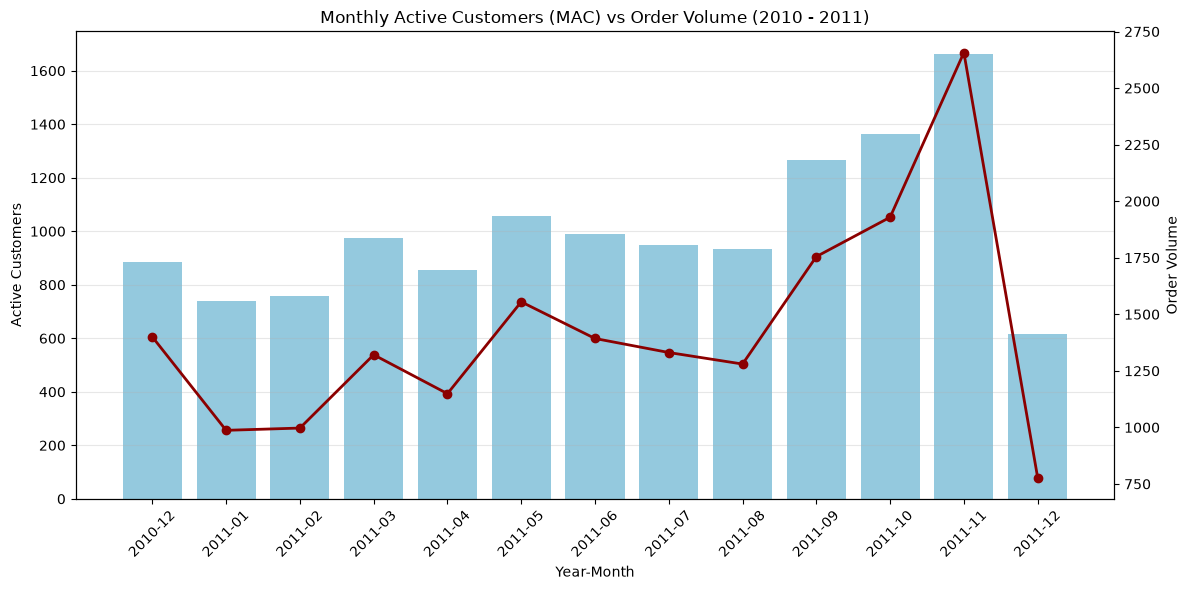

In [65]:
# Cell 32 - Monthly Active Customers (MAC) & Order Volume Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Convert YearMonth to string only for plotting
plot_data = monthly_metrics.copy()
plot_data["YearMonth_Label"] = plot_data["YearMonth"].astype(str)

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Active Customers - Bar Chart
sns.barplot(
    data=plot_data,
    x="YearMonth_Label",
    y="Active_Customers",
    color="skyblue",
    ax=ax1
)

ax1.set_xlabel("Year-Month")
ax1.set_ylabel("Active Customers")
ax1.tick_params(axis="x", rotation=45)

# Create secondary axis
ax2 = ax1.twinx()

# Plot Orders - Line Chart
ax2.plot(
    plot_data["YearMonth_Label"],
    plot_data["Orders"],
    color="darkred",
    marker="o",
    linewidth=2,
    label="Order Volume"
)

ax2.set_ylabel("Order Volume")

# Title and layout
plt.title(
    "Monthly Active Customers (MAC) vs Order Volume (2010 - 2011)"
)

ax1.grid(
    True,
    axis="y",
    alpha=0.3
)

fig.tight_layout()
plt.show()

In [34]:
# Cell 33 - Monthly Revenue vs Active Customers Correlation & Revenue per Order Trend
correlation = monthly_metrics["Active_Customers"].corr(monthly_metrics["Revenue"])
print(f"Correlation between Monthly Active Customers and Revenue: {correlation:.4f}")

# Summary Table of Core Monthly Metrics
monthly_metrics_summary = monthly_metrics[
    ["YearMonth", "Active_Customers", "Orders", "Revenue", "Revenue_per_Active_Customer"]
]
monthly_metrics_summary

Correlation between Monthly Active Customers and Revenue: 0.9502


,YearMonth,Active_Customers,Orders,Revenue,Revenue_per_Active_Customer
0,2010-12,885,1400,"570,422.73",644.55
1,2011-01,741,987,"568,101.31",766.67
2,2011-02,758,997,"446,084.92",588.50
3,2011-03,974,1321,"594,081.76",609.94
4,2011-04,856,1149,"468,374.33",547.17
5,2011-05,1056,1555,"677,355.15",641.43
6,2011-06,991,1393,"660,046.05",666.04
7,2011-07,949,1331,"598,962.90",631.15
8,2011-08,935,1280,"644,051.04",688.82
9,2011-09,1266,1755,"950,690.20",750.94


In [35]:
# Cell 34 - Top 10 Countries by Total Revenue
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Country" if "Revenue" not in df_clean else "Revenue", ascending=False)
    .head(10)
)

country_revenue["Revenue_Share_%"] = (country_revenue["Revenue"] / df_clean["Revenue"].sum()) * 100

print(f"UK Revenue Share: {country_revenue[country_revenue['Country'] == 'United Kingdom']['Revenue_Share_%'].values[0]:.2f}%")
country_revenue

UK Revenue Share: 81.97%


,Country,Revenue,Revenue_Share_%
35,United Kingdom,"7,285,024.64",81.97
23,Netherlands,"285,446.34",3.21
10,EIRE,"265,262.46",2.98
14,Germany,"228,678.40",2.57
13,France,"208,934.31",2.35
0,Australia,"138,453.81",1.56
30,Spain,"61,558.56",0.69
32,Switzerland,"56,443.95",0.64
3,Belgium,"41,196.34",0.46
31,Sweden,"38,367.83",0.43


In [36]:
# Cell 35 - International vs domestic UK Revenue Split
uk_vs_international = df_clean.copy()
uk_vs_international["Market"] = uk_vs_international["Country"].apply(
    lambda x: "United Kingdom" if x == "United Kingdom" else "International"
)

market_summary = (
    uk_vs_international.groupby("Market")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique"),
    )
    .reset_index()
)

market_summary["Revenue_Share_%"] = (market_summary["Revenue"] / df_clean["Revenue"].sum()) * 100
market_summary["AOV"] = market_summary["Revenue"] / market_summary["Orders"]

market_summary

,Market,Revenue,Orders,Customers,Revenue_Share_%,AOV
0,International,"1,602,184.25",1886,418,18.03,849.51
1,United Kingdom,"7,285,024.64",16646,3920,81.97,437.64


In [37]:
# Cell 36 - Top 10 International Markets (Excluding UK)
top_international = (
    df_clean[df_clean["Country"] != "United Kingdom"]
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_international["Revenue_Share_%"] = (
    top_international["Revenue"] / df_clean[df_clean["Country"] != "United Kingdom"]["Revenue"].sum()
) * 100

top_international

,Country,Revenue,Orders,Customers,Revenue_Share_%
23,Netherlands,"285,446.34",94,9,17.82
10,EIRE,"265,262.46",260,3,16.56
14,Germany,"228,678.40",457,94,14.27
13,France,"208,934.31",389,87,13.04
0,Australia,"138,453.81",57,9,8.64
30,Spain,"61,558.56",90,30,3.84
32,Switzerland,"56,443.95",51,21,3.52
3,Belgium,"41,196.34",98,25,2.57
31,Sweden,"38,367.83",36,8,2.39
19,Japan,"37,416.37",19,8,2.34


C:\Users\balav\AppData\Local\Temp\ipykernel_12100\666717519.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


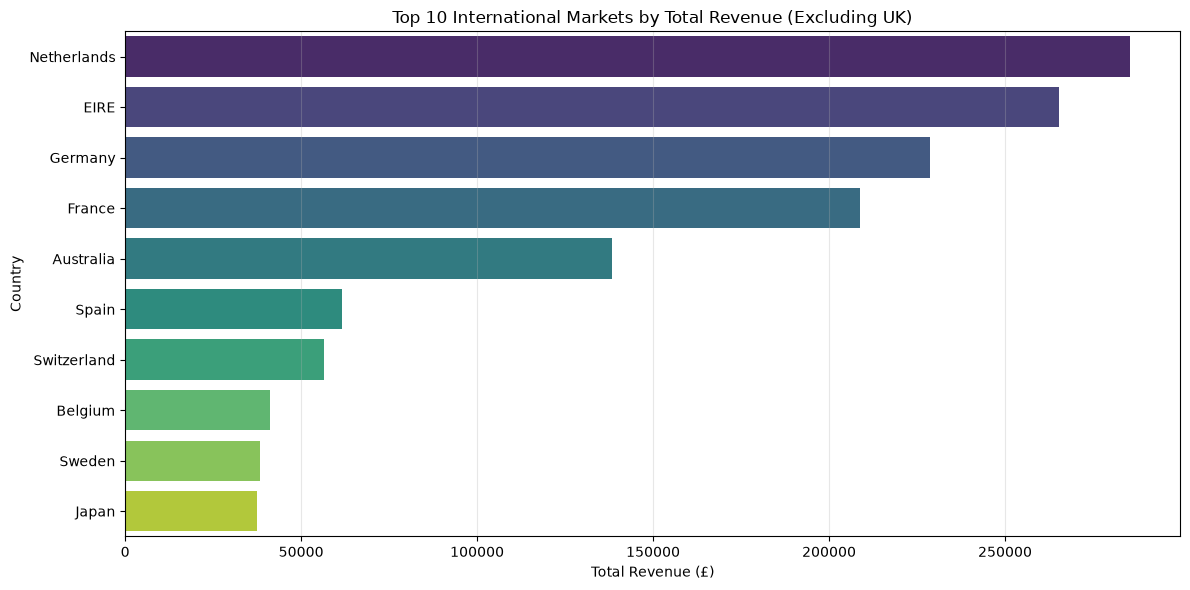

In [38]:
# Cell 37 - Visualization of Top 10 International Markets
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_international,
    x="Revenue",
    y="Country",
    palette="viridis"
)

plt.title("Top 10 International Markets by Total Revenue (Excluding UK)")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Country")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Cell 38 - Monthly Average Order Value (AOV) Analysis
monthly_aov = df_clean.groupby("YearMonth").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Orders=("InvoiceNo", "nunique")
).reset_index()

monthly_aov["AOV"] = monthly_aov["Total_Revenue"] / monthly_aov["Total_Orders"]
monthly_aov["AOV_MoM_Growth_%"] = monthly_aov["AOV"].pct_change() * 100

print(f"Overall Dataset AOV: £{df_clean['Revenue'].sum() / df_clean['InvoiceNo'].nunique():,.2f}")
print(f"Highest Monthly AOV: £{monthly_aov['AOV'].max():,.2f} ({monthly_aov.loc[monthly_aov['AOV'].idxmax(), 'YearMonth']})")
print(f"Lowest Monthly AOV: £{monthly_aov['AOV'].min():,.2f} ({monthly_aov.loc[monthly_aov['AOV'].idxmin(), 'YearMonth']})")

monthly_aov

Overall Dataset AOV: £479.56
Highest Monthly AOV: £664.77 (2011-12)
Lowest Monthly AOV: £407.44 (2010-12)


,YearMonth,Total_Revenue,Total_Orders,AOV,AOV_MoM_Growth_%
0,2010-12,"570,422.73",1400,407.44,NaN
1,2011-01,"568,101.31",987,575.58,41.27
2,2011-02,"446,084.92",997,447.43,-22.27
3,2011-03,"594,081.76",1321,449.72,0.51
4,2011-04,"468,374.33",1149,407.64,-9.36
5,2011-05,"677,355.15",1555,435.60,6.86
6,2011-06,"660,046.05",1393,473.83,8.78
7,2011-07,"598,962.90",1331,450.01,-5.03
8,2011-08,"644,051.04",1280,503.16,11.81
9,2011-09,"950,690.20",1755,541.70,7.66


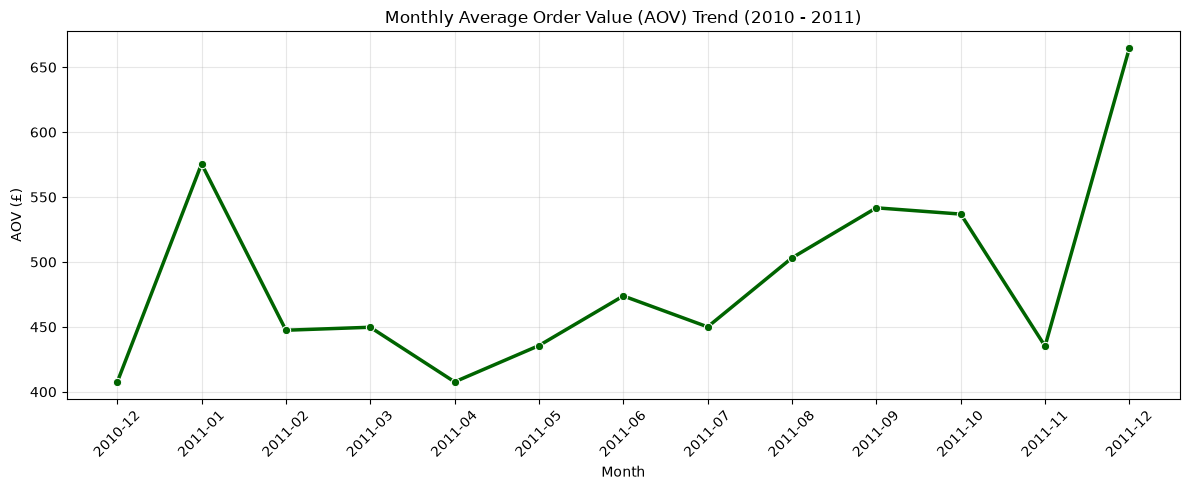

In [40]:
# Cell 39 - Monthly Average Order Value (AOV) Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_aov,
    x=monthly_aov["YearMonth"].astype(str),
    y="AOV",
    marker="o",
    color="darkgreen",
    linewidth=2.5
)

plt.title("Monthly Average Order Value (AOV) Trend (2010 - 2011)")
plt.xlabel("Month")
plt.ylabel("AOV (£)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# Cell 40 - Create Cohort Analysis Data Prep
def get_month(x): 
    return pd.Timestamp(x.year, x.month, 1)

df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].apply(get_month)
df_clean['CohortMonth'] = df_clean.groupby('CustomerID')['InvoiceMonth'].transform('min')

def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df_clean, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df_clean, 'CohortMonth')

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

df_clean['CohortIndex'] = years_diff * 12 + months_diff + 1

# Calculate Cohort Retention Matrix
cohort_data = df_clean.groupby(
    ['CohortMonth', 'CohortIndex']
)['CustomerID'].nunique().reset_index()

cohort_counts = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)

cohort_sizes = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide(
    cohort_sizes,
    axis=0
) * 100

print(
    f"Initial December 2010 Cohort Size: "
    f"{cohort_sizes.iloc[0]:,} customers"
)

# CohortIndex 1 = initial purchase month
# CohortIndex 2 = first subsequent month

print(
    f"First Subsequent Month Retention Rate "
    f"(Dec 2010 Cohort): "
    f"{retention.iloc[0, 1]:.2f}%"
)

retention.round(1)

Initial December 2010 Cohort Size: 885.0 customers
First Subsequent Month Retention Rate (Dec 2010 Cohort): 36.61%


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,100.00,36.60,32.30,38.40,36.30,39.80,36.30,34.90,35.40,39.50,37.40,50.30,26.60
2011-01-01,100.00,22.10,26.60,23.00,32.10,28.80,24.70,24.20,30.00,32.60,36.50,11.80,NaN
2011-02-01,100.00,18.70,18.70,28.40,27.10,24.70,25.30,27.90,24.70,30.50,6.80,NaN,NaN
2011-03-01,100.00,15.00,25.20,19.90,22.30,16.80,26.80,23.00,27.90,8.60,NaN,NaN,NaN
2011-04-01,100.00,21.30,20.30,21.00,19.70,22.70,21.70,26.00,7.30,NaN,NaN,NaN,NaN
2011-05-01,100.00,19.00,17.30,17.30,20.80,23.20,26.40,9.50,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.00,17.40,15.70,26.40,23.10,33.50,9.50,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.00,18.10,20.70,22.30,27.10,11.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.00,20.70,24.90,24.30,12.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


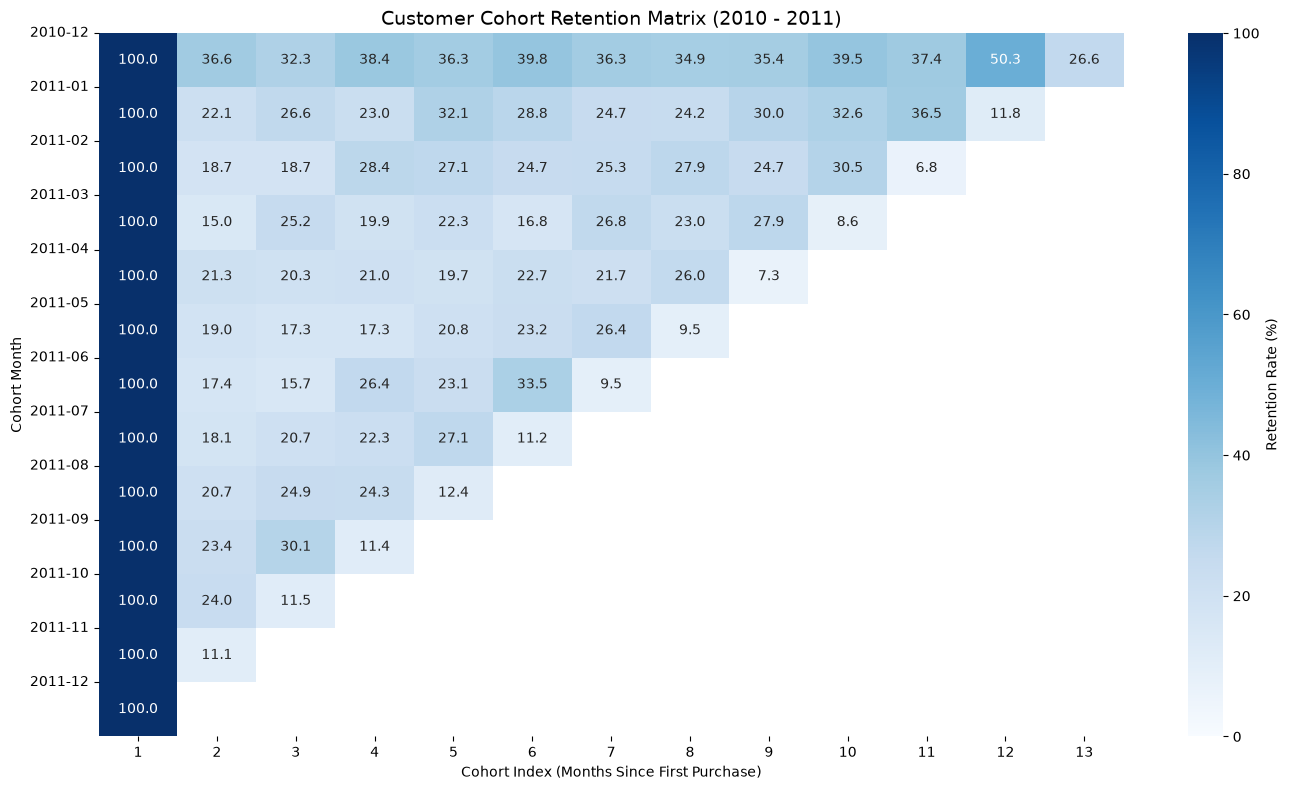

In [42]:
# Cell 41 - Cohort Retention Matrix Heatmap Visualization

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.heatmap(
    data=retention,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "Retention Rate (%)"}
)

plt.title(
    "Customer Cohort Retention Matrix (2010 - 2011)",
    fontsize=14
)

plt.xlabel(
    "Cohort Index (Months Since First Purchase)"
)

plt.ylabel("Cohort Month")

plt.yticks(
    ticks=range(len(retention.index)),
    labels=[str(x)[:7] for x in retention.index],
    rotation=0
)

plt.tight_layout()
plt.show()

In [43]:
# Cell 42 - Days Between Consecutive Purchases per Customer Analysis

df_orders = (
    df_clean
    .groupby(["CustomerID", "InvoiceNo", "InvoiceDate"])
    .size()
    .reset_index()
)

df_orders = df_orders[
    ["CustomerID", "InvoiceNo", "InvoiceDate"]
]

# Sort purchases chronologically for each customer
df_orders = (
    df_orders
    .sort_values(["CustomerID", "InvoiceDate"])
    .reset_index(drop=True)
)

df_orders["Prev_InvoiceDate"] = (
    df_orders
    .groupby("CustomerID")["InvoiceDate"]
    .shift(1)
)

df_orders["Days_Between_Purchases"] = (
    df_orders["InvoiceDate"]
    - df_orders["Prev_InvoiceDate"]
).dt.days

repeat_purchase_days = df_orders.dropna(
    subset=["Days_Between_Purchases"]
)

print(
    f"Average Days Between Purchases: "
    f"{repeat_purchase_days['Days_Between_Purchases'].mean():.1f} days"
)

print(
    f"Median Days Between Purchases: "
    f"{repeat_purchase_days['Days_Between_Purchases'].median():.1f} days"
)

display(
    repeat_purchase_days["Days_Between_Purchases"]
    .describe()
)

Average Days Between Purchases: 39.4 days
Median Days Between Purchases: 21.0 days


count   14,224.00
mean        39.44
std         51.82
min          0.00
25%          6.00
50%         21.00
75%         51.00
max        365.00
Name: Days_Between_Purchases, dtype: float64

In [44]:
# Cell 43 - Create Unit Price Tiers (Low, Medium, High, Premium)
price_bins = [-float("inf"), 1.0, 3.0, 10.0, float("inf")]
price_labels = ["Low (<£1)", "Medium (£1-£3)", "High (£3-£10)", "Premium (>£10)"]

df_clean["PriceTier"] = pd.cut(df_clean["UnitPrice"], bins=price_bins, labels=price_labels)

price_tier_summary = df_clean.groupby("PriceTier").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Total_Orders=("InvoiceNo", "nunique")
).reset_index()

price_tier_summary["Revenue_Share_%"] = (price_tier_summary["Total_Revenue"] / df_clean["Revenue"].sum()) * 100
price_tier_summary

,PriceTier,Total_Revenue,Total_Quantity,Total_Orders,Revenue_Share_%
0,Low (<£1),"1,047,523.15",2036396,13307,11.79
1,Medium (£1-£3),"4,362,289.26",2508317,16883,49.09
2,High (£3-£10),"2,810,750.57",569259,15178,31.63
3,Premium (>£10),"666,645.91",38030,6452,7.50


C:\Users\balav\AppData\Local\Temp\ipykernel_12100\949159248.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\balav\AppData\Local\Temp\ipykernel_12100\949159248.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


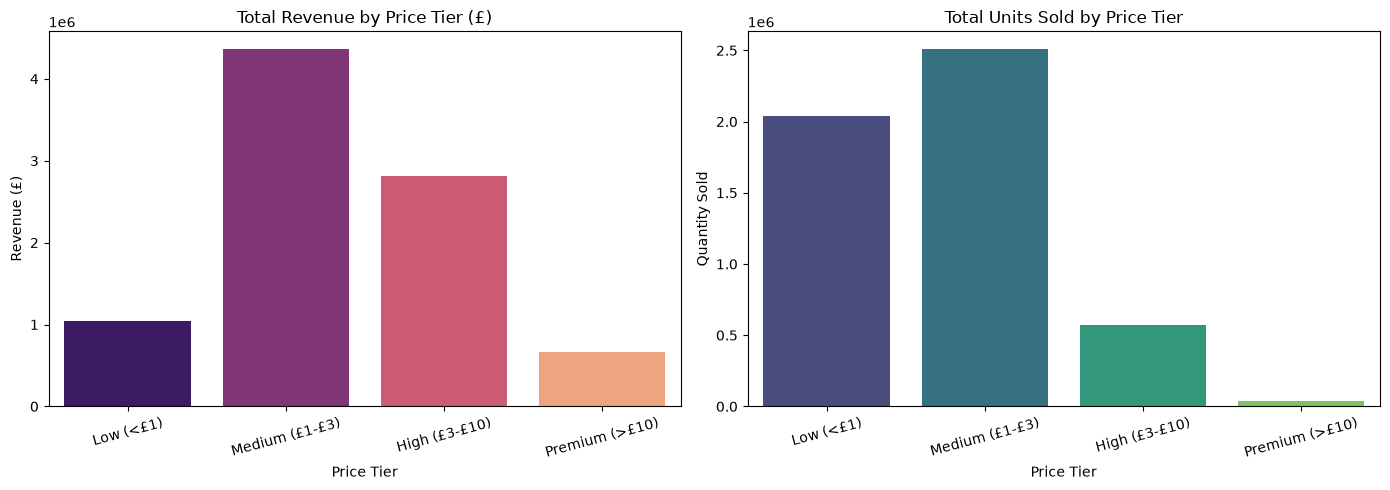

In [45]:
# Cell 44 - Price Tier Revenue & Quantity Distribution Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Revenue Share by Price Tier
sns.barplot(
    data=price_tier_summary,
    x="PriceTier",
    y="Total_Revenue",
    palette="magma",
    ax=axes[0]
)
axes[0].set_title("Total Revenue by Price Tier (£)")
axes[0].set_ylabel("Revenue (£)")
axes[0].set_xlabel("Price Tier")
axes[0].tick_params(axis="x", rotation=15)

# Plot 2: Total Units Sold by Price Tier
sns.barplot(
    data=price_tier_summary,
    x="PriceTier",
    y="Total_Quantity",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Total Units Sold by Price Tier")
axes[1].set_ylabel("Quantity Sold")
axes[1].set_xlabel("Price Tier")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [46]:
#Cell 45
# RFM Feature Calculation
import datetime as dt

# The RFM snapshot date is one day after the final transaction
# available in the dataset.
#
# Note:
# The dataset ends on 2011-12-09, so Recency represents
# recency relative to the final available transaction,
# not a complete calendar month.

# Set snapshot date as 1 day after the maximum date in the dataset
snapshot_date = df_clean["InvoiceDate"].max() + dt.timedelta(days=1)

# Calculate RFM metrics per CustomerID
rfm = (
    df_clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum"),
    )
    .reset_index()
)

print(f"Snapshot Date for Recency Calculation: {snapshot_date}")
print(f"Total Customers Processed for RFM: {len(rfm):,}")
rfm.head()

Snapshot Date for Recency Calculation: 2011-12-10 12:50:00
Total Customers Processed for RFM: 4,338


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,"77,183.60"
1,12347,2,7,"4,310.00"
2,12348,75,4,"1,797.24"
3,12349,19,1,"1,757.55"
4,12350,310,1,334.40


In [47]:
# Cell 46 - RFM Statistical Summary & Distribution Metrics
print("--- RFM Descriptive Statistics ---")
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

# Check Skewness across RFM Features
print("\n--- Feature Skewness ---")
print(f"Recency Skewness:  {rfm['Recency'].skew():.2f}")
print(f"Frequency Skewness: {rfm['Frequency'].skew():.2f}")
print(f"Monetary Skewness:  {rfm['Monetary'].skew():.2f}")

--- RFM Descriptive Statistics ---


,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,048.69"
std,100.01,7.70,"8,985.23"
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,"1,660.60"
max,374.00,209.00,"280,206.02"



--- Feature Skewness ---
Recency Skewness:  1.25
Frequency Skewness: 12.07
Monetary Skewness:  19.34


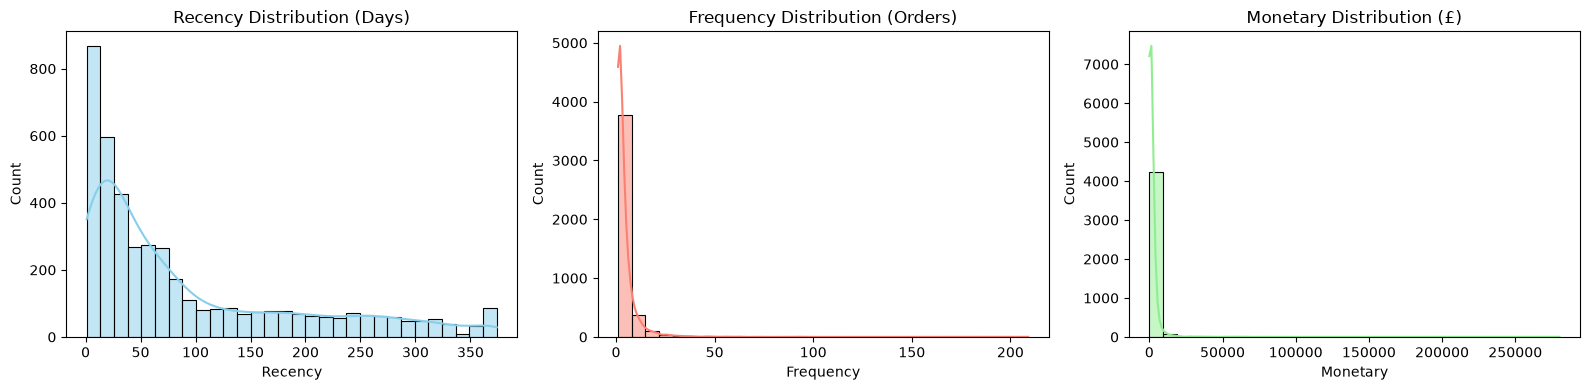

In [48]:
# Cell 47 - RFM Distributions Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Recency Distribution (Days)")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Frequency Distribution (Orders)")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2], color="lightgreen")
axes[2].set_title("Monetary Distribution (£)")

plt.tight_layout()
plt.show()

In [49]:
# Cell 48 - Log Transformation for Skewed RFM Features
import numpy as np

rfm_log = rfm.copy()

# Apply log1p transformation to eliminate extreme skewness
rfm_log["Recency_Log"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency_Log"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary_Log"] = np.log1p(rfm_log["Monetary"])

print("--- Post-Transformation Skewness Check ---")
print(f"Recency Log Skewness:   {rfm_log['Recency_Log'].skew():.2f}")
print(f"Frequency Log Skewness: {rfm_log['Frequency_Log'].skew():.2f}")
print(f"Monetary Log Skewness:  {rfm_log['Monetary_Log'].skew():.2f}")

rfm_log[["CustomerID", "Recency_Log", "Frequency_Log", "Monetary_Log"]].head()

--- Post-Transformation Skewness Check ---
Recency Log Skewness:   -0.38
Frequency Log Skewness: 1.21
Monetary Log Skewness:  0.40


,CustomerID,Recency_Log,Frequency_Log,Monetary_Log
0,12346,5.79,0.69,11.25
1,12347,1.10,2.08,8.37
2,12348,4.33,1.61,7.49
3,12349,3.00,0.69,7.47
4,12350,5.74,0.69,5.82


In [50]:
# Cell 49 - Scale Log-Transformed RFM Features for K-Means Clustering
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled_data = scaler.fit_transform(rfm_log[["Recency_Log", "Frequency_Log", "Monetary_Log"]])

# Store scaled data in a DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled_data,
    columns=["Recency_Scaled", "Frequency_Scaled", "Monetary_Scaled"],
    index=rfm_log["CustomerID"]
).reset_index()

print("--- Scaled RFM Features Summary ---")
print(f"Mean (should be ~0): {rfm_scaled[['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled']].mean().values.round(4)}")
print(f"Std Dev (should be 1): {rfm_scaled[['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled']].std().values.round(4)}")

rfm_scaled.head()

--- Scaled RFM Features Summary ---
Mean (should be ~0): [-0. -0. -0.]
Std Dev (should be 1): [1.0001 1.0001 1.0001]


,CustomerID,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,12346,1.46,-0.96,3.71
1,12347,-2.04,1.07,1.41
2,12348,0.37,0.39,0.72
3,12349,-0.62,-0.96,0.70
4,12350,1.42,-0.96,-0.61


In [51]:
# Cell 50 - Determine Optimal Number of Clusters (Elbow Method & Silhouette Score)

# Determine Optimal Number of Clusters
# Using Elbow Method and Silhouette Score
#
# Note:
# K=2 achieves the highest silhouette score.
# However, K=4 is considered for the final business segmentation
# because it provides more granular and actionable customer personas.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_rfm = rfm_scaled[["Recency_Scaled", "Frequency_Scaled", "Monetary_Scaled"]]

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_rfm)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_rfm, kmeans.labels_))

# Display Metrics Table
cluster_metrics = pd.DataFrame({
    "Clusters (K)": list(k_range),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

cluster_metrics.round(4)

,Clusters (K),Inertia,Silhouette Score
0,2,"6,483.59",0.43
1,3,"4,869.49",0.34
2,4,"3,939.05",0.34
3,5,"3,296.71",0.32
4,6,"2,855.76",0.31
5,7,"2,548.82",0.31
6,8,"2,336.34",0.30
7,9,"2,156.01",0.28
8,10,"2,005.75",0.28


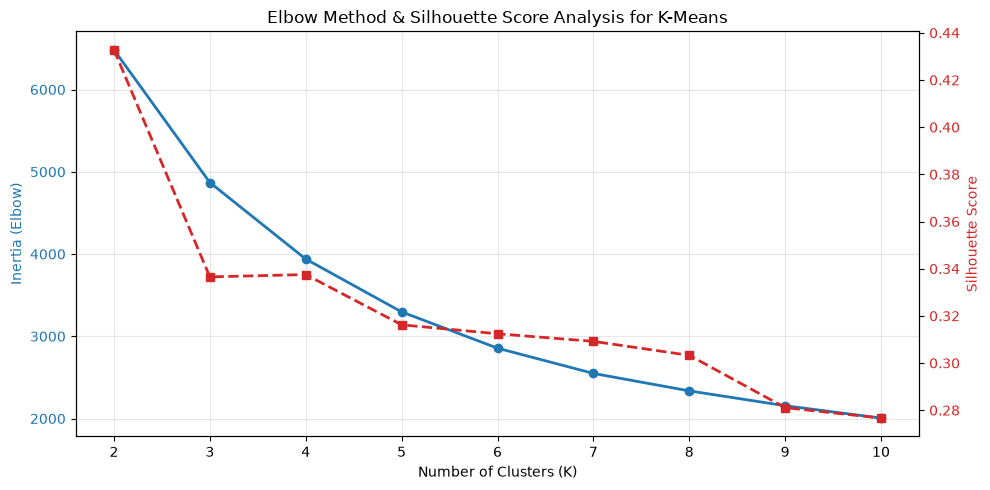

In [52]:
# Cell 51 - Visualize Elbow Curve and Silhouette Scores
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Elbow)', color=color)
ax1.plot(cluster_metrics["Clusters (K)"], cluster_metrics["Inertia"], marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(cluster_metrics["Clusters (K)"], cluster_metrics["Silhouette Score"], marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Elbow Method & Silhouette Score Analysis for K-Means")
fig.tight_layout()
plt.show()

In [53]:
# Cell 52 - Fit Final K-Means Model (K = 4) & Assign Cluster Labels
# Fit Final K-Means Model (K = 4) & Assign Cluster Labels
#
# K=2 produced the highest silhouette score.
# K=4 is selected here to provide more actionable
# business-oriented customer segments.

final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = final_kmeans.fit_predict(X_rfm)

# Count customers per cluster
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

print("--- Customer Count by Cluster ---")
display(cluster_counts)

--- Customer Count by Cluster ---


Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

In [54]:
# Cell 53 - Aggregate RFM Profile Summary per Cluster
cluster_profile = (
    rfm.groupby("Cluster")
    .agg(
        Customer_Count=("CustomerID", "count"),
        Recency_Mean=("Recency", "mean"),
        Frequency_Mean=("Frequency", "mean"),
        Monetary_Mean=("Monetary", "mean"),
        Monetary_Median=("Monetary", "median"),
        Total_Cluster_Revenue=("Monetary", "sum"),
    )
    .reset_index()
)

cluster_profile["Revenue_Share_%"] = (
    cluster_profile["Total_Cluster_Revenue"] / rfm["Monetary"].sum()
) * 100

print("--- Cluster Profiles Summary ---")
cluster_profile.round(2)

--- Cluster Profiles Summary ---


,Cluster,Customer_Count,Recency_Mean,Frequency_Mean,Monetary_Mean,Monetary_Median,Total_Cluster_Revenue,Revenue_Share_%
0,0,713,12.17,13.75,"8,088.02","3,722.82","5,766,757.07",64.89
1,1,1622,181.51,1.32,341.00,296.09,"553,099.77",6.22
2,2,837,17.70,2.19,557.32,480.31,"466,479.03",5.25
3,3,1166,71.64,4.08,"1,801.78","1,345.20","2,100,873.02",23.64


In [ ]:
# Cell 54 - Map Cluster IDs to Business Persona Labels
# Map Cluster IDs to Business Persona Labels
#
# Cluster interpretation is based on the RFM profile
# calculated in Cell 53.
#
# Lower Recency = more recent customer activity
# Higher Frequency = more repeat purchases
# Higher Monetary = higher customer value

persona_map = {
    0: "Champions (High Value)",
    1: "At Risk / Dormant",
    2: "New / Low-Value",
    3: "Loyal Customers"
}

rfm["Customer_Segment"] = (
    rfm["Cluster"]
    .map(persona_map)
)

# Customer segment summary
segment_distribution = (
    rfm.groupby("Customer_Segment")
    .agg(
        Customer_Count=("CustomerID", "count"),
        Recency_Avg=("Recency", "mean"),
        Frequency_Avg=("Frequency", "mean"),
        Monetary_Avg=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .reset_index()
)

segment_distribution["Revenue_Share_%"] = (
    segment_distribution["Total_Revenue"]
    / rfm["Monetary"].sum()
) * 100

print("--- Final Customer Persona Segmentation Summary ---")

display(
    segment_distribution.round(2)
)

--- Final Customer Persona Segmentation Summary ---


,Customer_Segment,Customer_Count,Recency_Avg,Frequency_Avg,Monetary_Avg,Total_Revenue,Revenue_Share_%
0,At Risk / Dormant,1622,181.51,1.32,341.00,"553,099.77",6.22
1,Champions (High Value),713,12.17,13.75,"8,088.02","5,766,757.07",64.89
2,Loyal Customers,1166,71.64,4.08,"1,801.78","2,100,873.02",23.64
3,New / Low-Value,837,17.70,2.19,557.32,"466,479.03",5.25


C:\Users\balav\AppData\Local\Temp\ipykernel_12100\1163819840.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_distribution, x="Customer_Segment", y="Recency_Avg", palette="coolwarm", ax=axes[0, 0])
C:\Users\balav\AppData\Local\Temp\ipykernel_12100\1163819840.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_distribution, x="Customer_Segment", y="Frequency_Avg", palette="viridis", ax=axes[0, 1])
C:\Users\balav\AppData\Local\Temp\ipykernel_12100\1163819840.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(dat

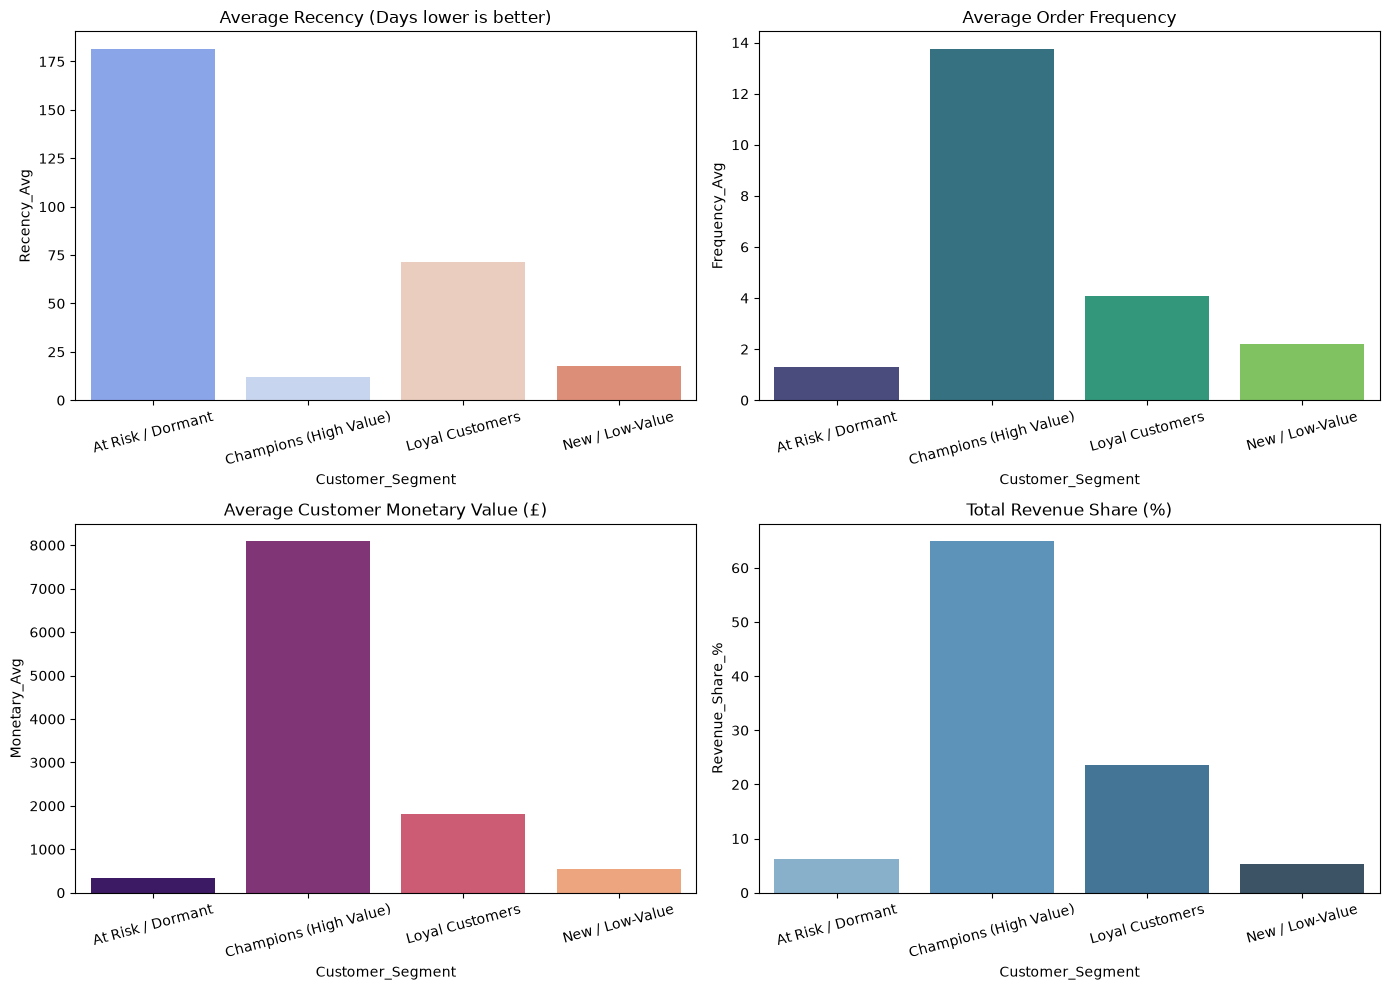

In [56]:
# Cell 55 - Visualize Customer Segment Profiles
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Average Recency
sns.barplot(data=segment_distribution, x="Customer_Segment", y="Recency_Avg", palette="coolwarm", ax=axes[0, 0])
axes[0, 0].set_title("Average Recency (Days lower is better)")
axes[0, 0].tick_params(axis="x", rotation=15)

# Plot 2: Average Frequency
sns.barplot(data=segment_distribution, x="Customer_Segment", y="Frequency_Avg", palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Average Order Frequency")
axes[0, 1].tick_params(axis="x", rotation=15)

# Plot 3: Average Monetary Value
sns.barplot(data=segment_distribution, x="Customer_Segment", y="Monetary_Avg", palette="magma", ax=axes[1, 0])
axes[1, 0].set_title("Average Customer Monetary Value (£)")
axes[1, 0].tick_params(axis="x", rotation=15)

# Plot 4: Revenue Share %
sns.barplot(data=segment_distribution, x="Customer_Segment", y="Revenue_Share_%", palette="Blues_d", ax=axes[1, 1])
axes[1, 1].set_title("Total Revenue Share (%)")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

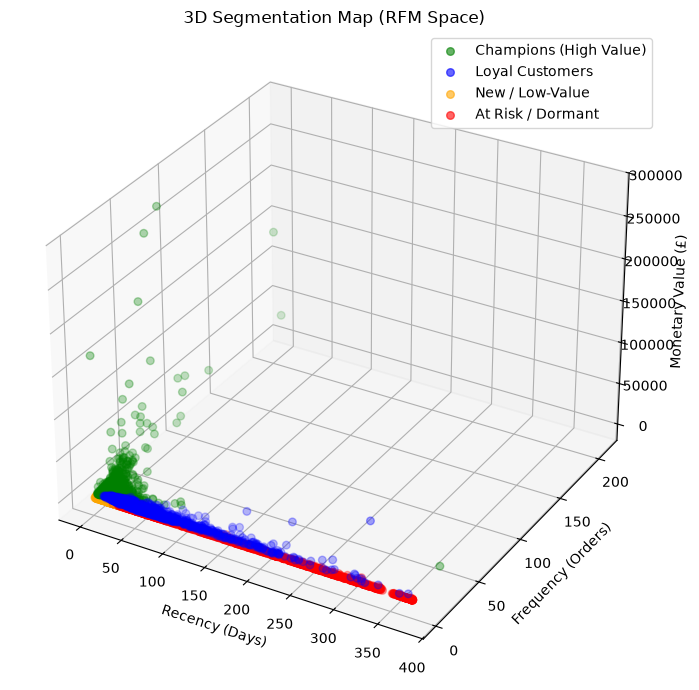

In [57]:
# Cell 56 - 3D Visual Analysis of Customer Segments
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

colors = {"Champions (High Value)": "green", "Loyal Customers": "blue", 
          "New / Low-Value": "orange", "At Risk / Dormant": "red"}

for segment, color in colors.items():
    subset = rfm[rfm["Customer_Segment"] == segment]
    ax.scatter(subset["Recency"], subset["Frequency"], subset["Monetary"], 
               c=color, label=segment, alpha=0.6, s=30)

ax.set_xlabel("Recency (Days)")
ax.set_ylabel("Frequency (Orders)")
ax.set_zlabel("Monetary Value (£)")
ax.set_title("3D Segmentation Map (RFM Space)")
plt.legend()
plt.tight_layout()
plt.show()

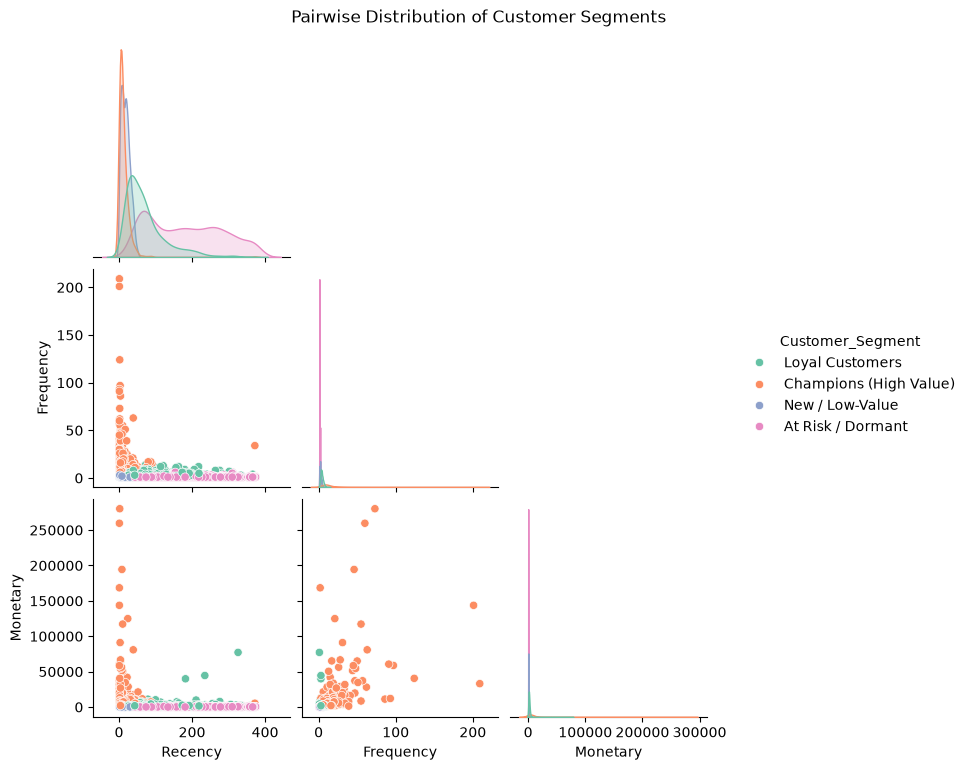

In [58]:
# Cell 57 - Pairplot of Customer Segments across RFM Metrics
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    rfm[["Recency", "Frequency", "Monetary", "Customer_Segment"]],
    hue="Customer_Segment",
    palette="Set2",
    diag_kind="kde",
    corner=True
)
plt.suptitle("Pairwise Distribution of Customer Segments", y=1.02)
plt.show()

In [59]:
# Cell 58 - Export Labeled Customer RFM Dataset
rfm.to_csv("customer_rfm_segments.csv", index=False)
print("Customer RFM segmentation dataset saved as 'customer_rfm_segments.csv'!")

Customer RFM segmentation dataset saved as 'customer_rfm_segments.csv'!


In [60]:
# Cell 59 - Project Execution Summary Report
print("==================================================")
print("   CUSTOMER PURCHASE INTELLIGENCE - FINAL PIPELINE   ")
print("==================================================")
print(f"Total Unique Customers Analyzed: {len(rfm):,}")
print(f"Total Segments Identified:        {rfm['Customer_Segment'].nunique()}")
print("--------------------------------------------------")
for segment, count in rfm["Customer_Segment"].value_counts().items():
    rev_share = (rfm[rfm["Customer_Segment"] == segment]["Monetary"].sum() / rfm["Monetary"].sum()) * 100
    print(f"• {segment:<23}: {count:>5,} customers ({rev_share:.2f}% revenue share)")
print("==================================================")

   CUSTOMER PURCHASE INTELLIGENCE - FINAL PIPELINE   
Total Unique Customers Analyzed: 4,338
Total Segments Identified:        4
--------------------------------------------------
• At Risk / Dormant      : 1,622 customers (6.22% revenue share)
• Loyal Customers        : 1,166 customers (23.64% revenue share)
• New / Low-Value        :   837 customers (5.25% revenue share)
• Champions (High Value) :   713 customers (64.89% revenue share)
